# Can we extrapolate how much the proportions would change if we change the resuspension parameter?

In [3]:
import cmocean.cm as cm
import copy
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.colors as mcolors
#
from shapely.geometry import Polygon, Point
from shapely.plotting import plot_polygon
from matplotlib.path import Path
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
from scipy.stats import linregress
import seaborn as sns
import matplotlib.collections as collections
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')

In [4]:
data_all_versions = pd.read_excel('/ocean/vvalenzuela/MOAD/analysis-vicente/Ocean_Parcels/PBDE_simulations/All_versions_simulation_tuning.xlsx')
data_all_versions  = data_all_versions.drop(columns='Unnamed: 0')
#
data_all_versions = data_all_versions[~((data_all_versions['Tau'] < 0.015) & (data_all_versions['[S1]'] < 2e-8))]
data_all_versions = data_all_versions.reset_index(drop=True)

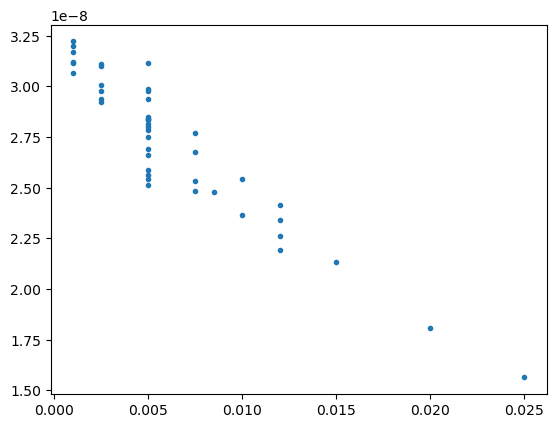

In [5]:
plt.plot(data_all_versions['Tau'], data_all_versions['[S1]'], '.')

In [6]:
regression_result = linregress(data_all_versions['Tau'], data_all_versions['p_water_S1'])

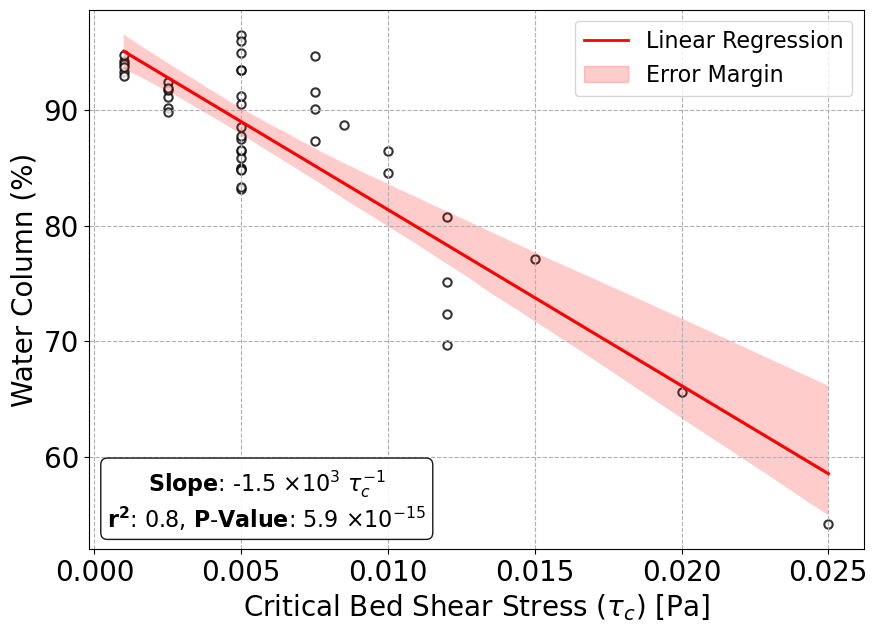

In [7]:
plt.rcParams.update({'font.size': 20})
#
fig, ax = plt.subplots(figsize=(10, 7))

ax.grid(linestyle = '--')

sns.regplot(
    x=data_all_versions['Tau'], 
    y=data_all_versions['p_water_S1'], 
    ax=ax,
    color='red', 
    scatter_kws={
        'facecolors': 'white', 
        'edgecolors': 'black', 
        'linewidths': 1.5
    }
)

for collection in ax.collections:
    if isinstance(collection, collections.PolyCollection):
        collection.set_alpha(0.2)

# 
ax.set_xlabel(r'Critical Bed Shear Stress ($\tau_{c}$) [Pa]')
ax.set_ylabel('Water Column (%)')

stats_text = (
    r"$\mathbf{Slope}$: -1.5 $\times$10$^{3}$ $\tau_{c}^{-1}$" + '\n'
    rf"$\mathbf{{r^2}}$: 0.8, " + r"$\mathbf{P}$-$\mathbf{Value}$: 5.9 $\times$10$^{-15}$"
)

textbox_props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='k')
ax.text(
    0.23, 0.03, 
    stats_text, 
    transform=ax.transAxes, 
    fontsize=16,
    verticalalignment='bottom', 
    horizontalalignment='center', 
    bbox=textbox_props
)

line_proxy = Line2D(
    [0], [0], 
    color='red', linewidth=2, 
    label='Linear Regression'
)

fill_proxy = Patch(
    color='red', alpha=0.2, 
    label='Error Margin'
)
ax.legend(handles=[line_proxy, fill_proxy], loc='upper right', frameon=True, fontsize = 16)


In [23]:
regression_result

LinregressResult(slope=-1525.3492571792392, intercept=96.6462636724637, rvalue=-0.8770413586856108, pvalue=5.8841836020591986e-15, stderr=128.92615315992123, intercept_stderr=1.0315465664404941)

In [31]:
-1525.3492571792392*0.001 + 96.6462636724637

95.12091441528446

In [22]:
1500*0.001

1.5

In [20]:
93-30

63

In [10]:
regression_result.pvalue

5.8841836020591986e-15